In [20]:
import os
import sys
from pathlib import Path

# Resolve repository root and set working directory
root = Path.cwd().resolve()
while root != root.parent:
    if (root / 'src').exists() and (root / 'config').exists():
        break
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))
os.chdir(root)
print(f"Working directory: {root}")


Working directory: C:\Users\given\Downloads\dozer-predictive-maintenance\dozer_predictive_maintenance


# 02. Exploratory Data Analysis & Sensor Degradation

Statistical exploration covering sensor distributions, correlation heatmaps, hierarchical clustering dendrograms, grouped outlier boxplots, and multi-panel degradation trajectories.


In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from src.data.load_data import load_workbook
from src.utils.io import load_config

sns.set_theme(style="whitegrid")
config = load_config()
workbook = load_workbook(config["project"]["raw_file"])
telemetry = workbook["telemetry"].sort_values(["Machine ID", "Timestamp"]).reset_index(drop=True)
events = workbook["events"]

# Identify sensor columns and enforce numeric types
non_sensor_cols = {"Machine ID", "Timestamp", "Event Timestamp", "target_failure", "SMR"}
sensor_cols = [col for col in telemetry.columns if col not in non_sensor_cols]

for col in sensor_cols:
    telemetry[col] = pd.to_numeric(telemetry[col], errors="coerce")

print(f"Identified {len(sensor_cols)} Sensor Channels:")
print(sensor_cols)


Identified 22 Sensor Channels:
['Engine Speed Max', 'Engine Speed Avg', 'Blow-by Press Max', 'Oil Press LoIdle Min', 'Oil Press HiIdle Min', 'Oil Temp Max', 'Coolant Temp Max', 'Boost Press Max', 'LB Front Exh Temp', 'LB Rear Exh Temp', 'RB Front Exh Temp', 'RB Rear Exh Temp', 'Fuel Rate', 'Hyd Oil Temp Max', 'Front Pump Press Max', 'Rear Pump Press Max', 'TM Main Press Max', 'TC Oil Temp Max', 'Ambient Temp Max', 'Pitch Angle Max', 'Operating Hours', 'Pass Times']


## 1. Sensor Distributions Across Dozers


C:\Users\given\AppData\Local\Temp\ipykernel_17096\2727904204.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=telemetry, x=col, hue="Machine ID", common_norm=False, ax=axes[idx], fill=True, alpha=0.15, legend=(idx==0))


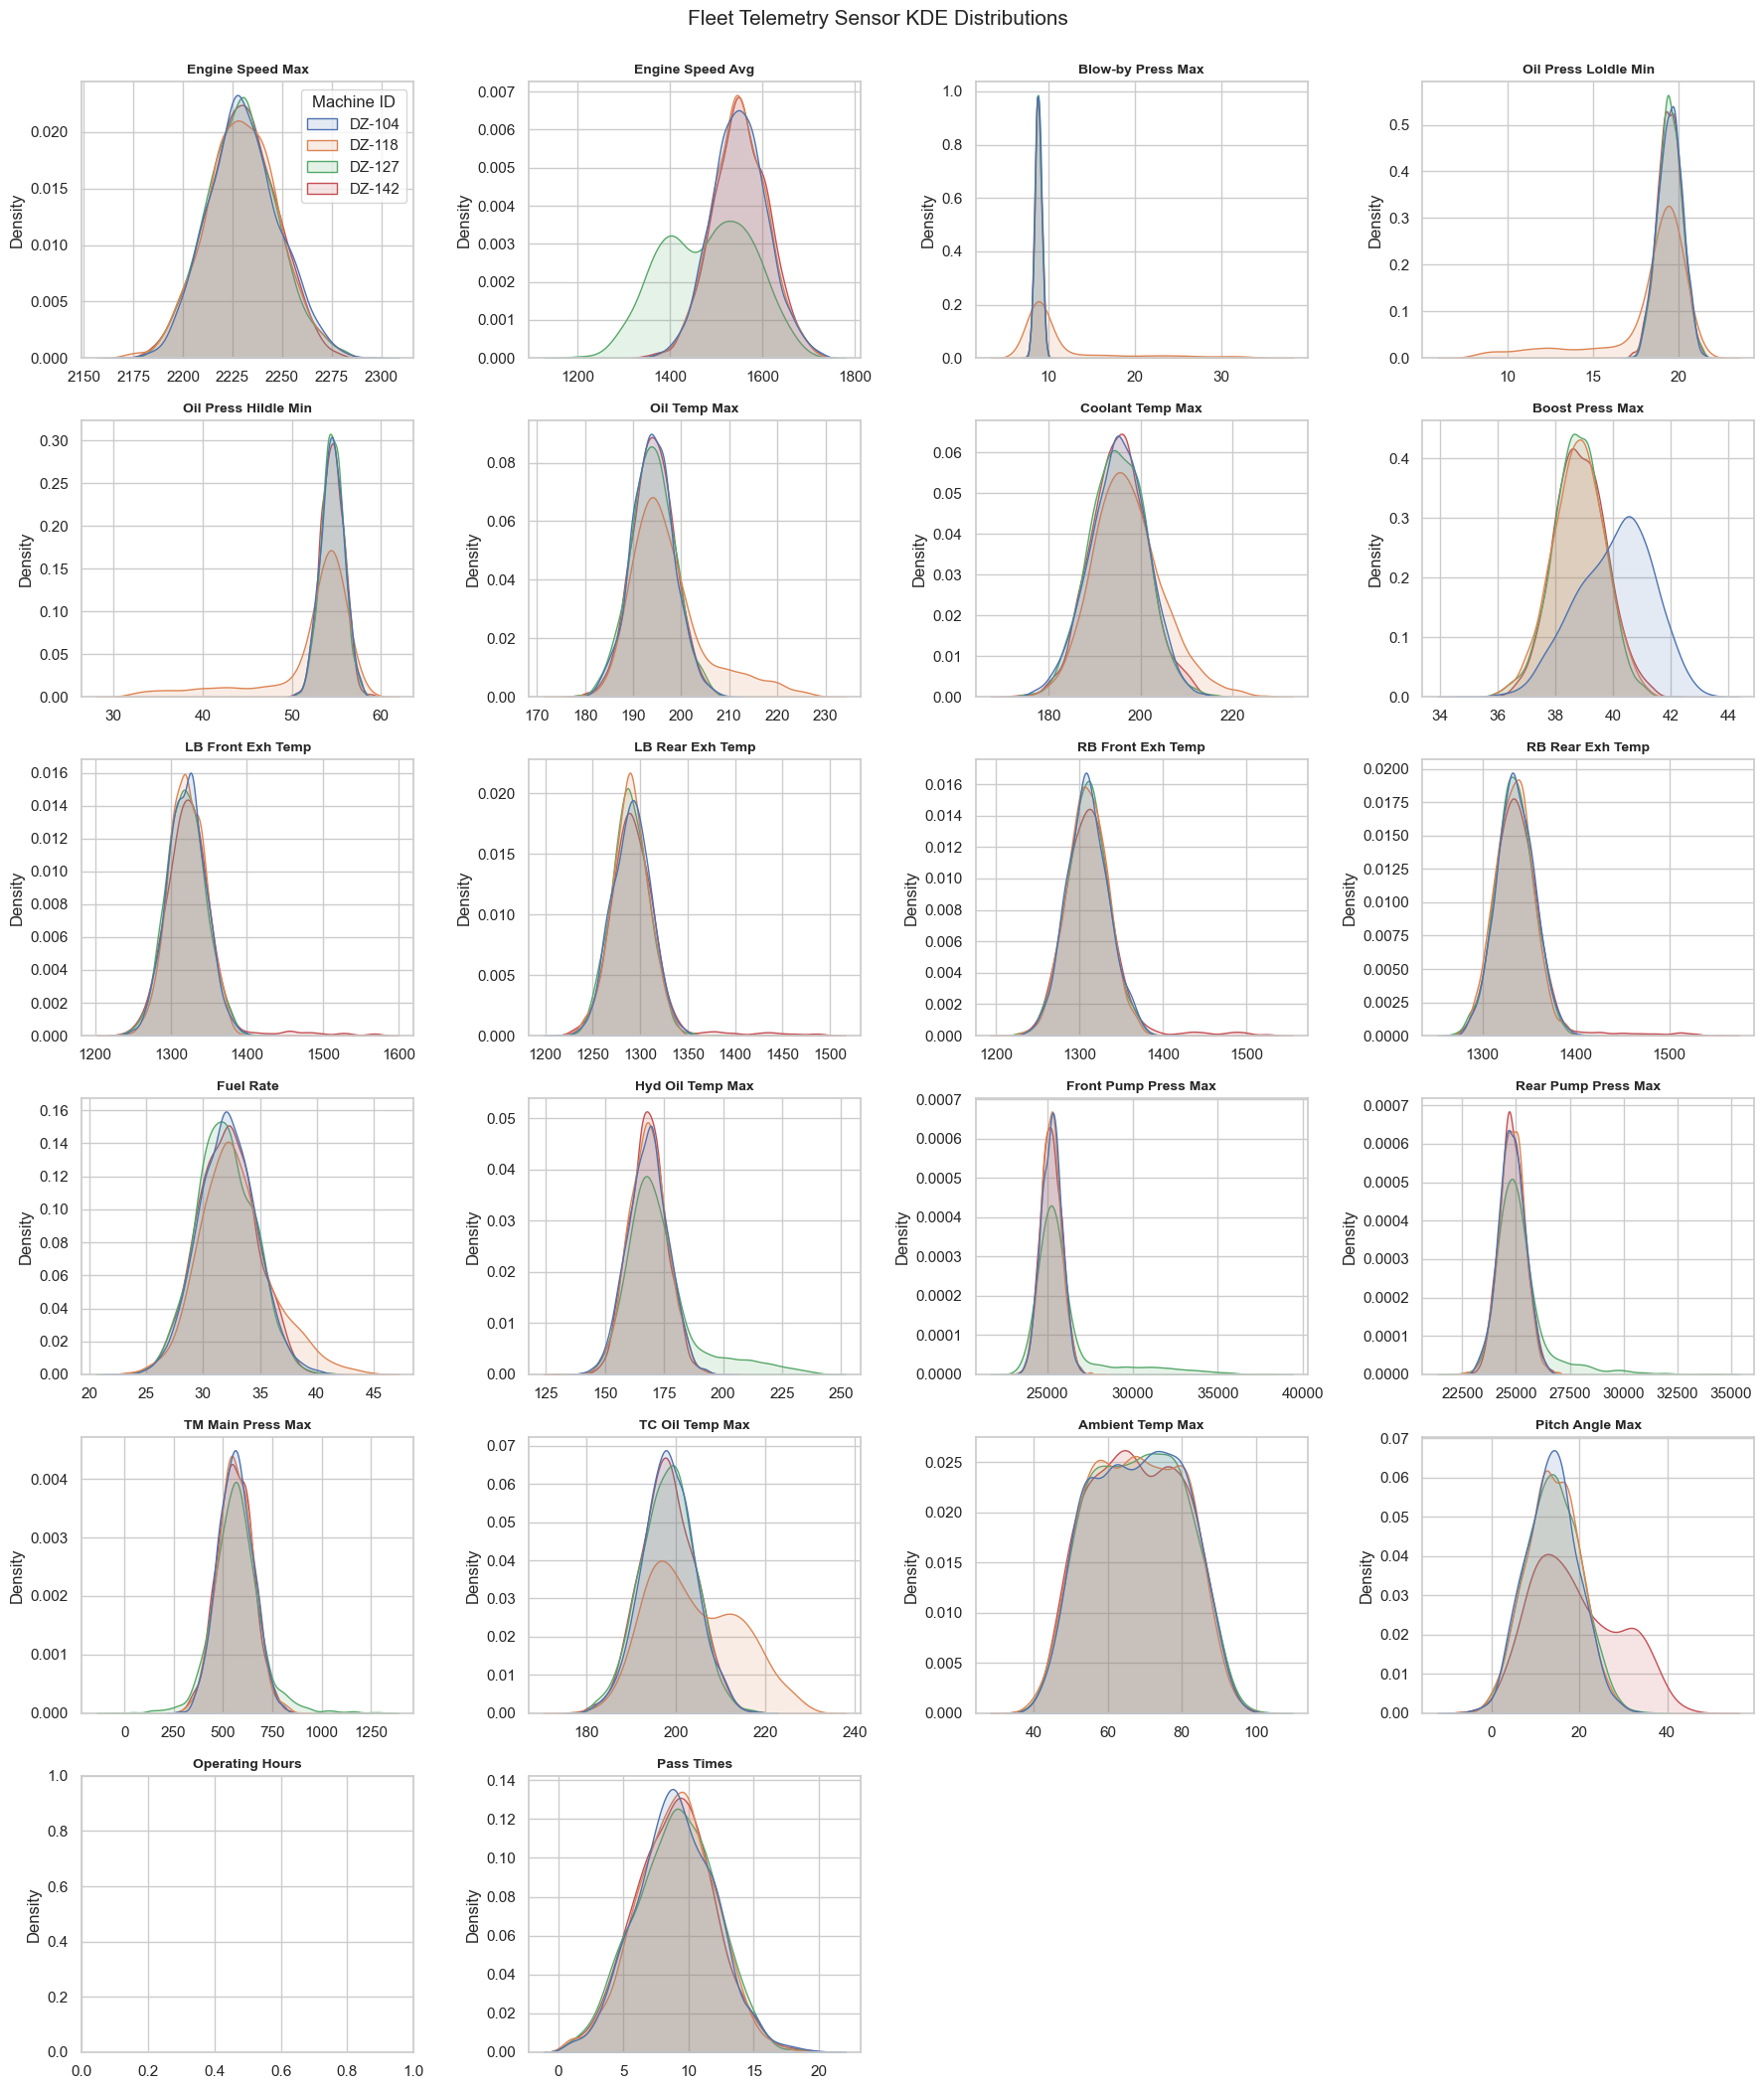

In [22]:
n_cols = len(sensor_cols)
rows = int(np.ceil(n_cols / 4))
fig, axes = plt.subplots(rows, 4, figsize=(18, rows * 3.5))
axes = np.array(axes).flatten()

for idx, col in enumerate(sensor_cols):
    sns.kdeplot(data=telemetry, x=col, hue="Machine ID", common_norm=False, ax=axes[idx], fill=True, alpha=0.15, legend=(idx==0))
    axes[idx].set_title(col, fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("")

for ax in axes[n_cols:]:
    ax.axis("off")

plt.suptitle("Fleet Telemetry Sensor KDE Distributions", fontsize=15, y=1.00)
plt.tight_layout()
plt.show()


## 2. Multi-Collinearity Heatmap (|r| > 0.75 Focus)


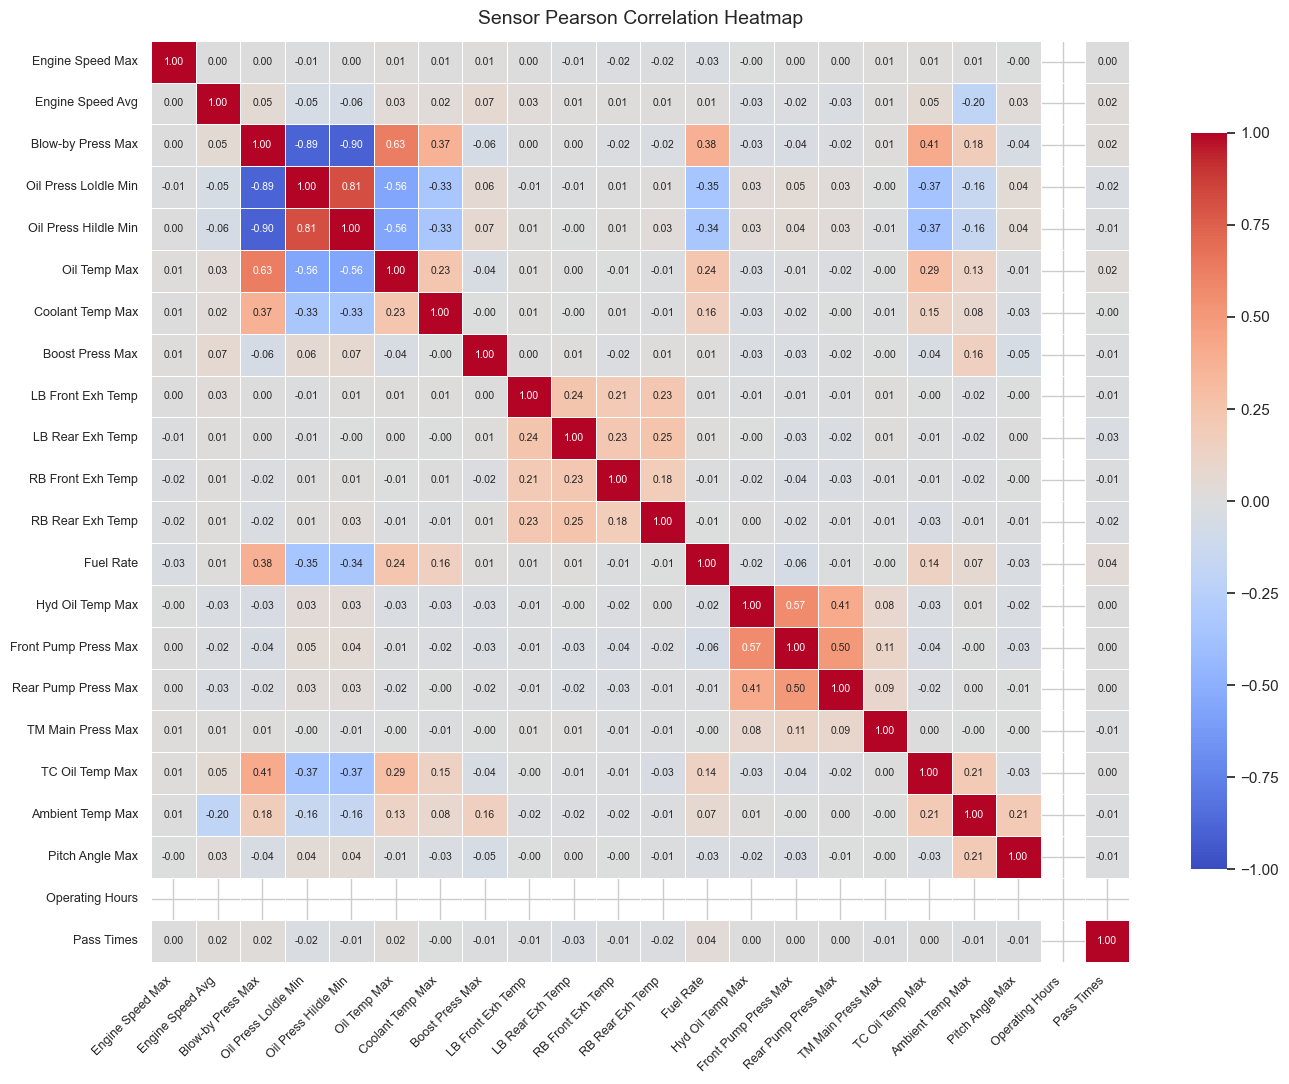

=== Highly Correlated Sensor Pairs (|r| > 0.75) ===


,Feature_1,Feature_2,Correlation
57,Oil Press LoIdle Min,Oil Press HiIdle Min,0.812578
39,Blow-by Press Max,Oil Press LoIdle Min,-0.890255
40,Blow-by Press Max,Oil Press HiIdle Min,-0.904004


In [23]:
corr_matrix = telemetry[sensor_cols].corr()

# Full correlation matrix without overlapping text
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    annot_kws={"size": 7.5}, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Sensor Pearson Correlation Heatmap", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# High correlation pairs report
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_tri.stack().reset_index()
high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"].abs() > 0.75].sort_values(by="Correlation", ascending=False)

print("=== Highly Correlated Sensor Pairs (|r| > 0.75) ===")
display(high_corr_pairs)


## 3. Hierarchical Feature Clustering Dendrogram


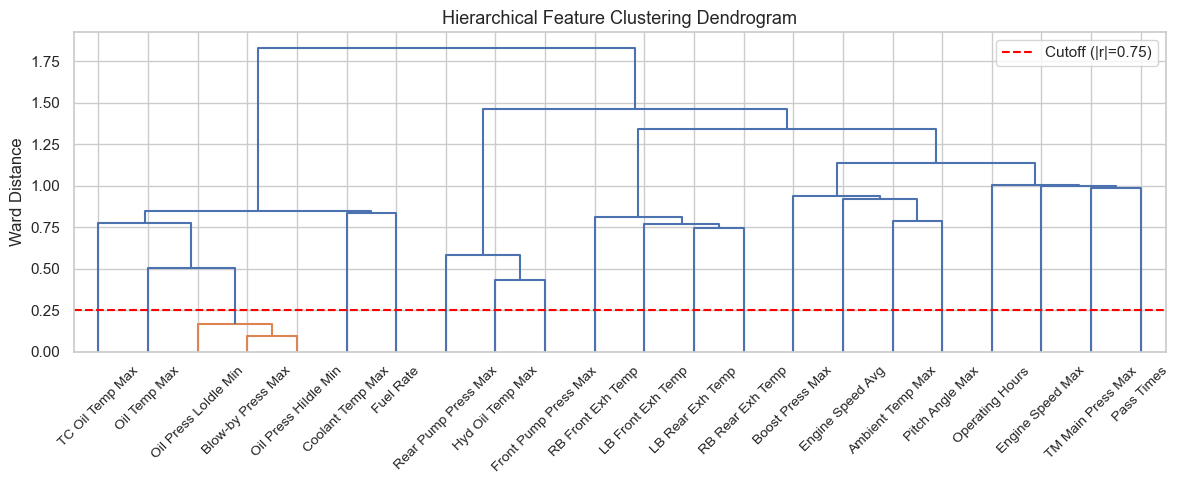

In [24]:
distance_matrix = (1 - abs(corr_matrix.fillna(0))).values
condensed_dist = squareform(distance_matrix, checks=False)

plt.figure(figsize=(12, 5))
dend = sch.linkage(condensed_dist, method="ward")
sch.dendrogram(dend, labels=sensor_cols, leaf_rotation=45, color_threshold=0.25)
plt.axhline(y=0.25, color="red", linestyle="--", label="Cutoff (|r|=0.75)")
plt.title("Hierarchical Feature Clustering Dendrogram", fontsize=13)
plt.ylabel("Ward Distance")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Outlier Inspection via Grouped Boxplots (4 Columns Layout)


C:\Users\given\AppData\Local\Temp\ipykernel_17096\999297726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=telemetry, x="Machine ID", y=col, ax=axes[idx], palette="Set2")
C:\Users\given\AppData\Local\Temp\ipykernel_17096\999297726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=telemetry, x="Machine ID", y=col, ax=axes[idx], palette="Set2")
C:\Users\given\AppData\Local\Temp\ipykernel_17096\999297726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=telemetry, x="Machine ID", y=col, ax=axes[idx], palette="Set2")
C:\U

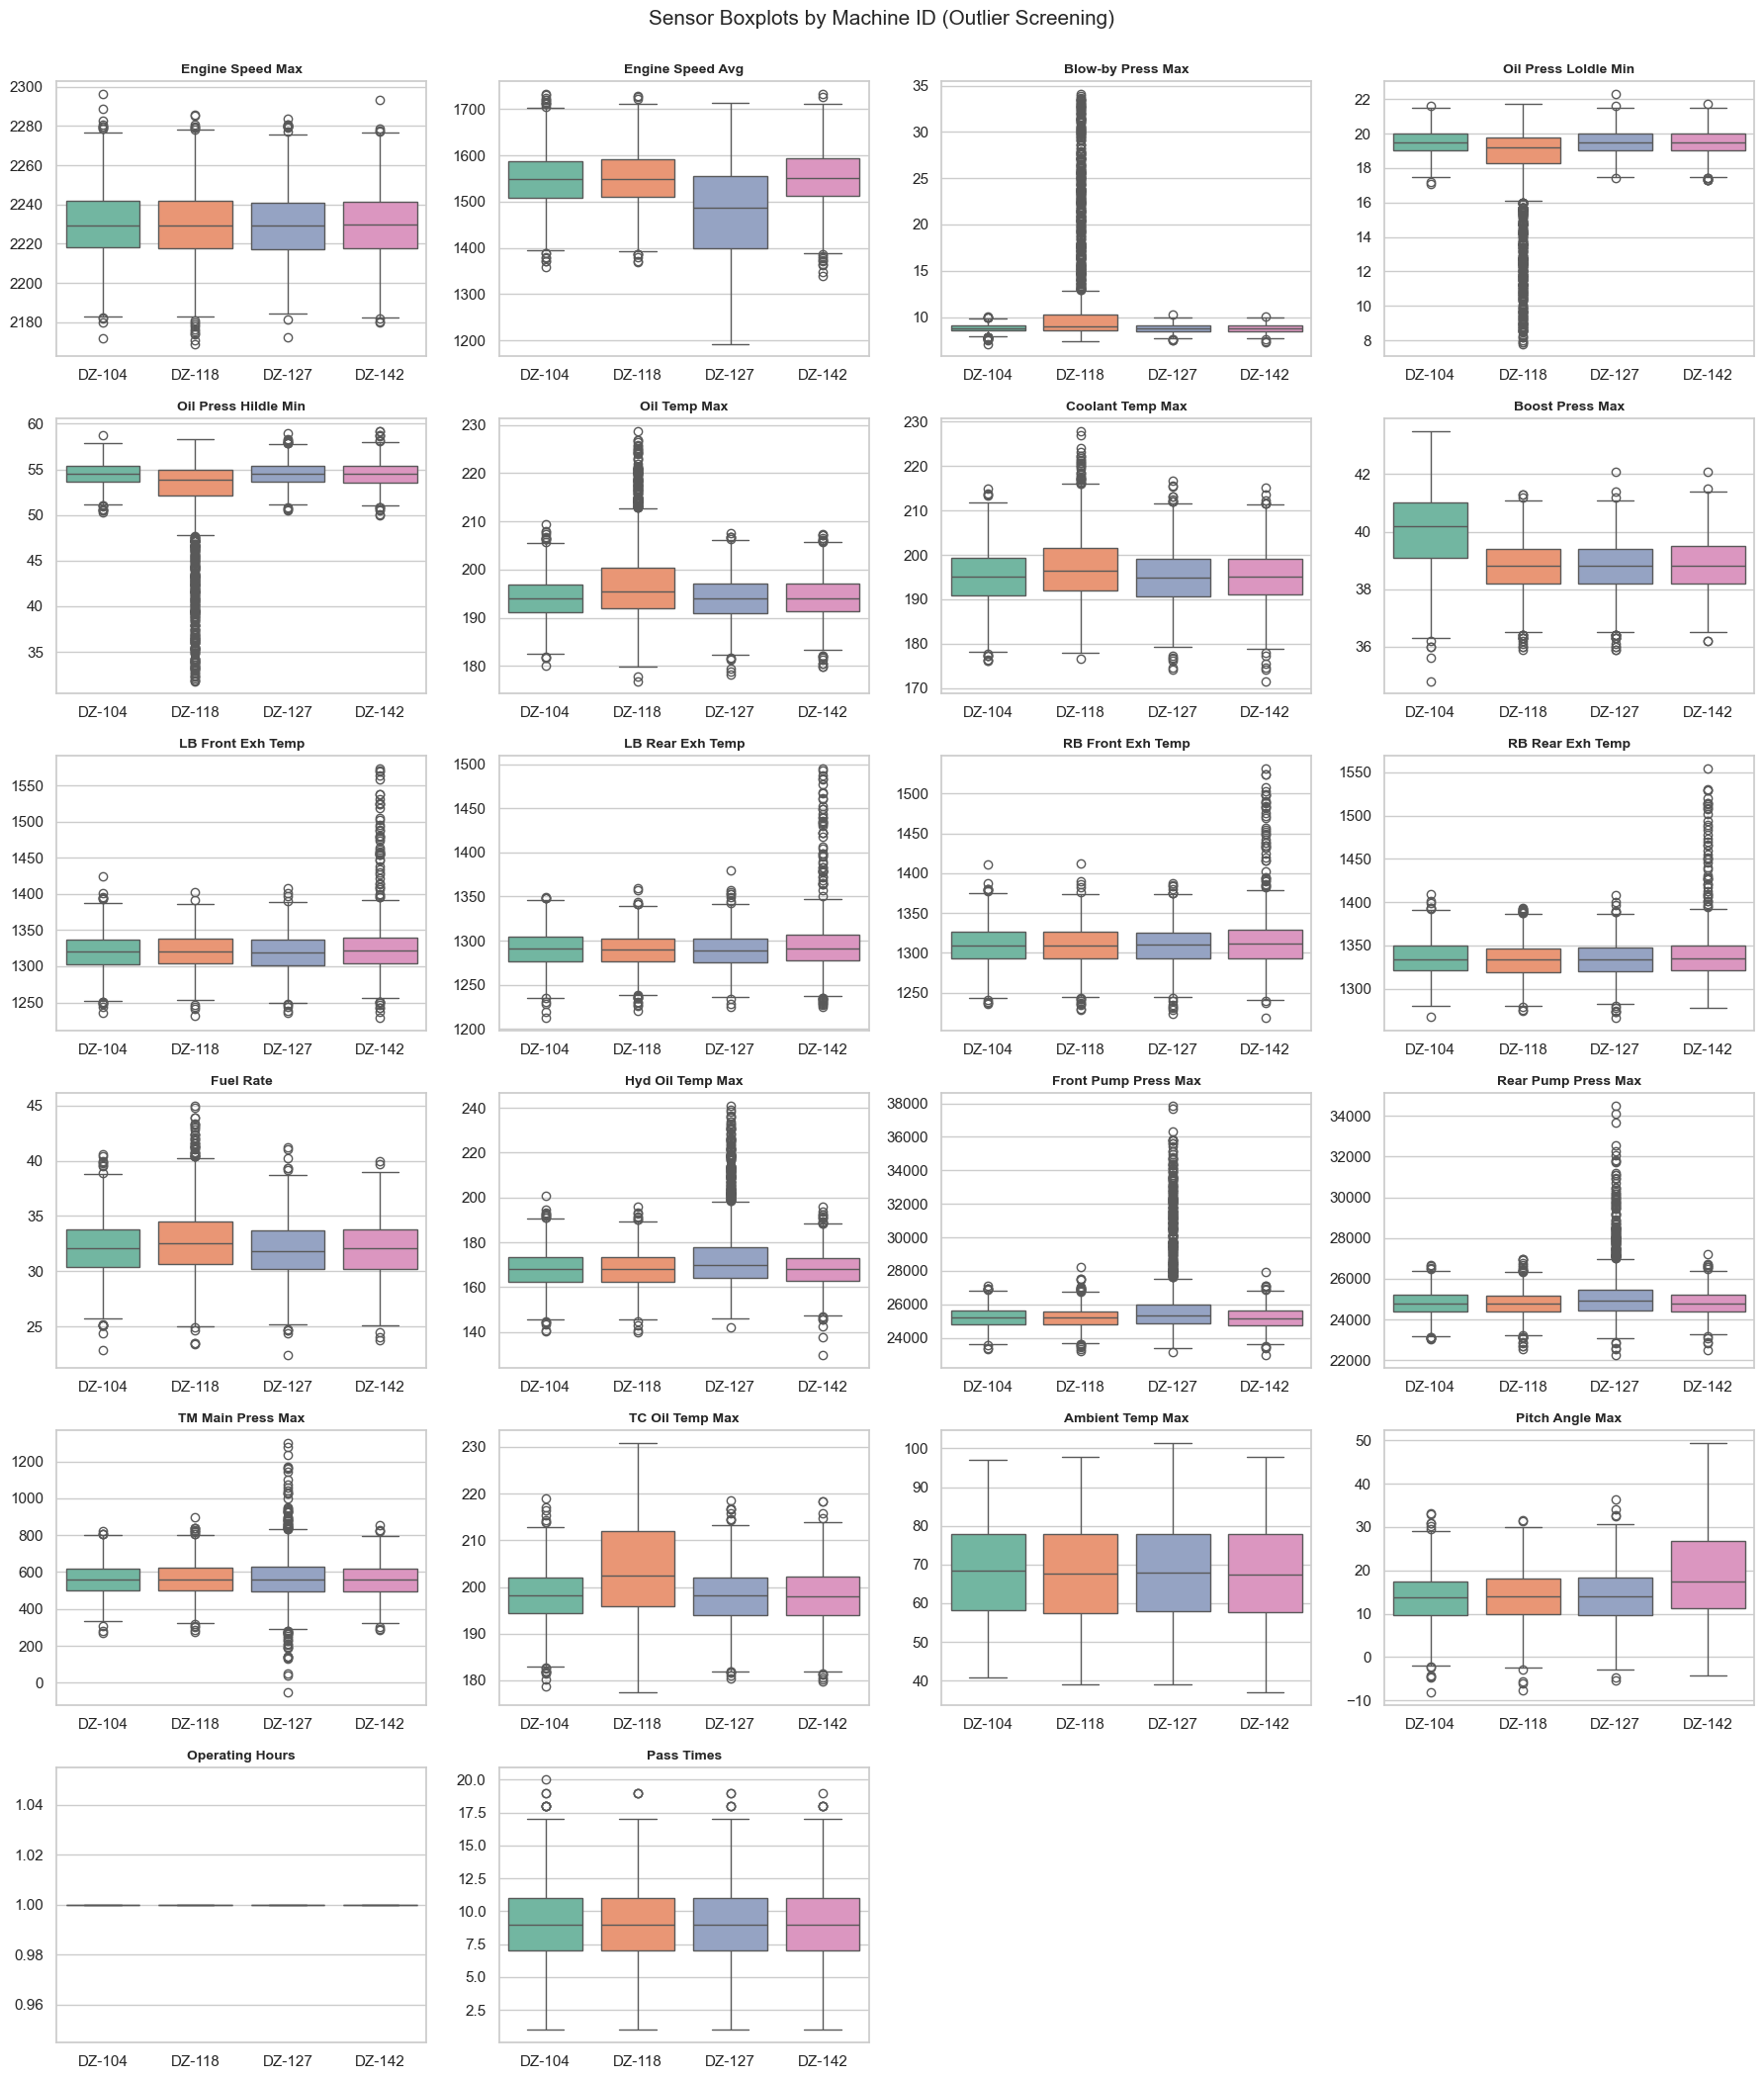

In [25]:
n_cols = len(sensor_cols)
rows = int(np.ceil(n_cols / 4))
fig, axes = plt.subplots(rows, 4, figsize=(18, rows * 3.5))
axes = np.array(axes).flatten()

for idx, col in enumerate(sensor_cols):
    sns.boxplot(data=telemetry, x="Machine ID", y=col, ax=axes[idx], palette="Set2")
    axes[idx].set_title(col, fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")

for ax in axes[n_cols:]:
    ax.axis("off")

plt.suptitle("Sensor Boxplots by Machine ID (Outlier Screening)", fontsize=15, y=1.00)
plt.tight_layout()
plt.show()


## 5. Sub-System Degradation Trajectories (Separated Y-Axes)

Sensors are split into Temperatures (deg C), Pressures (kPa/psi), and Speeds/Operational channels to avoid scale flattening.


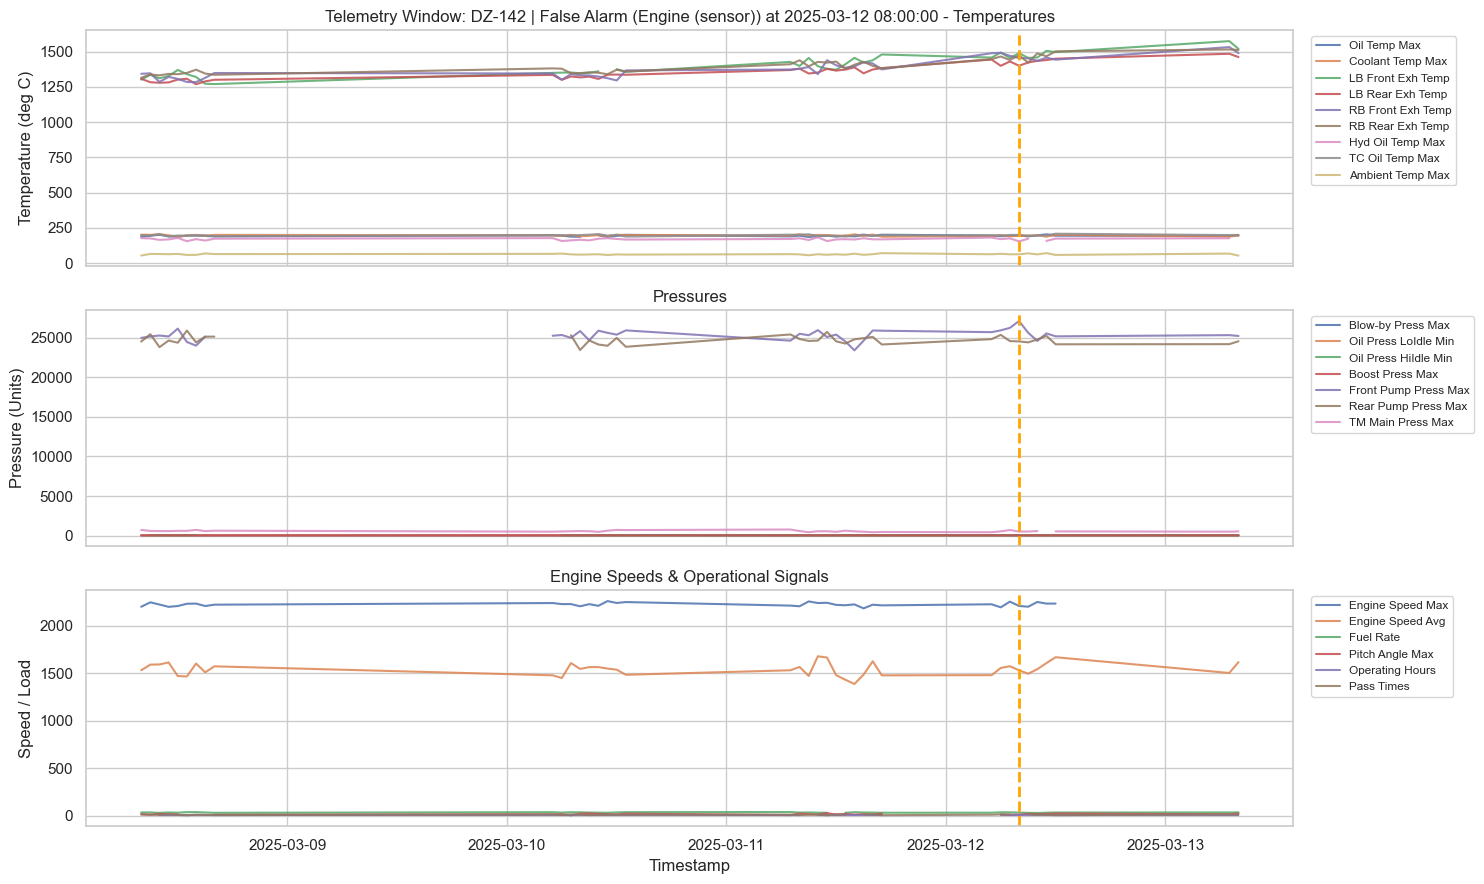

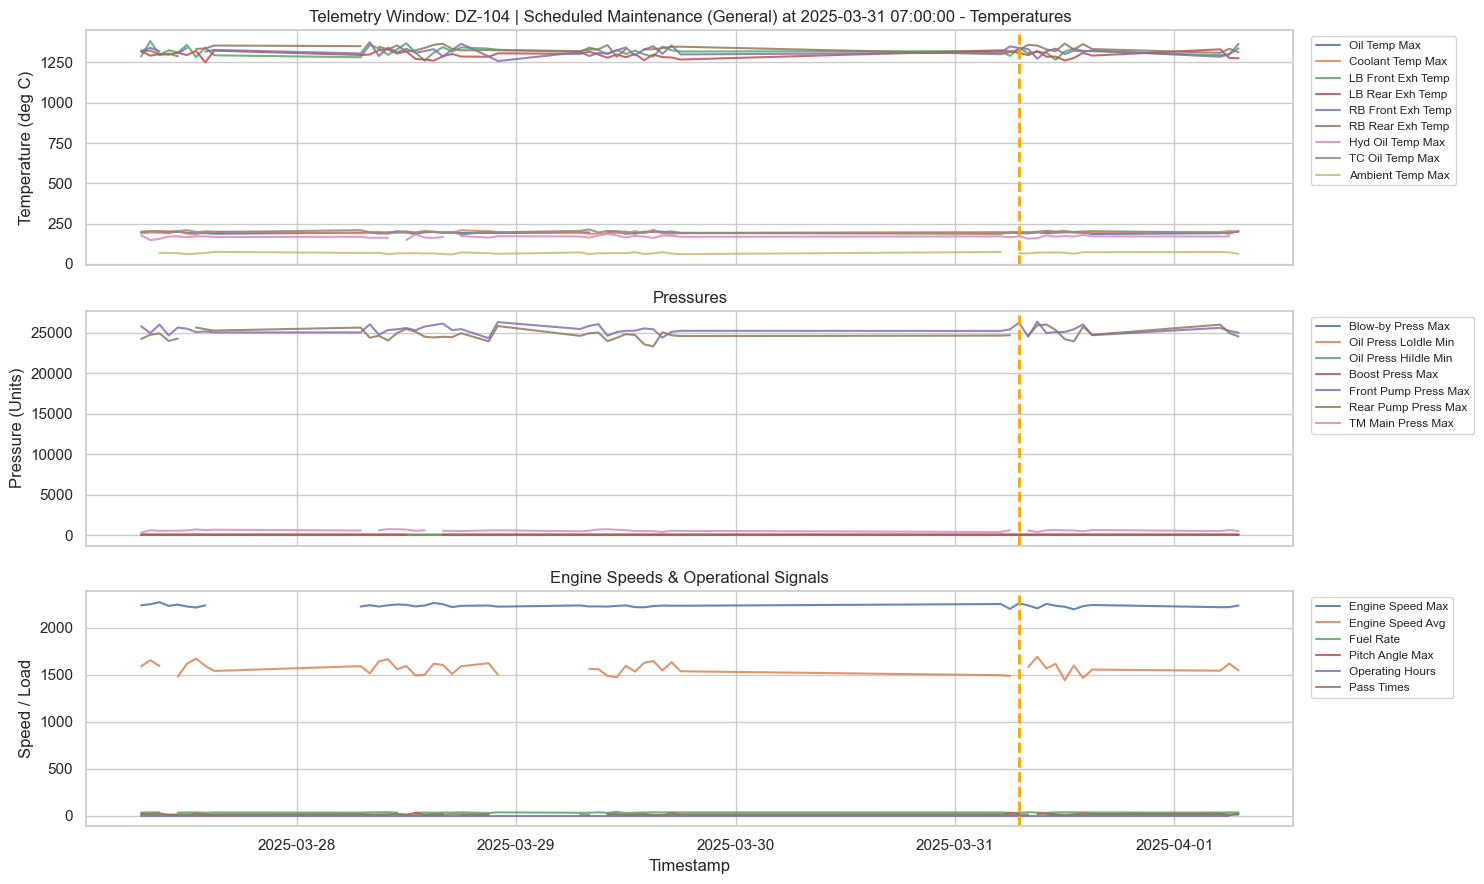

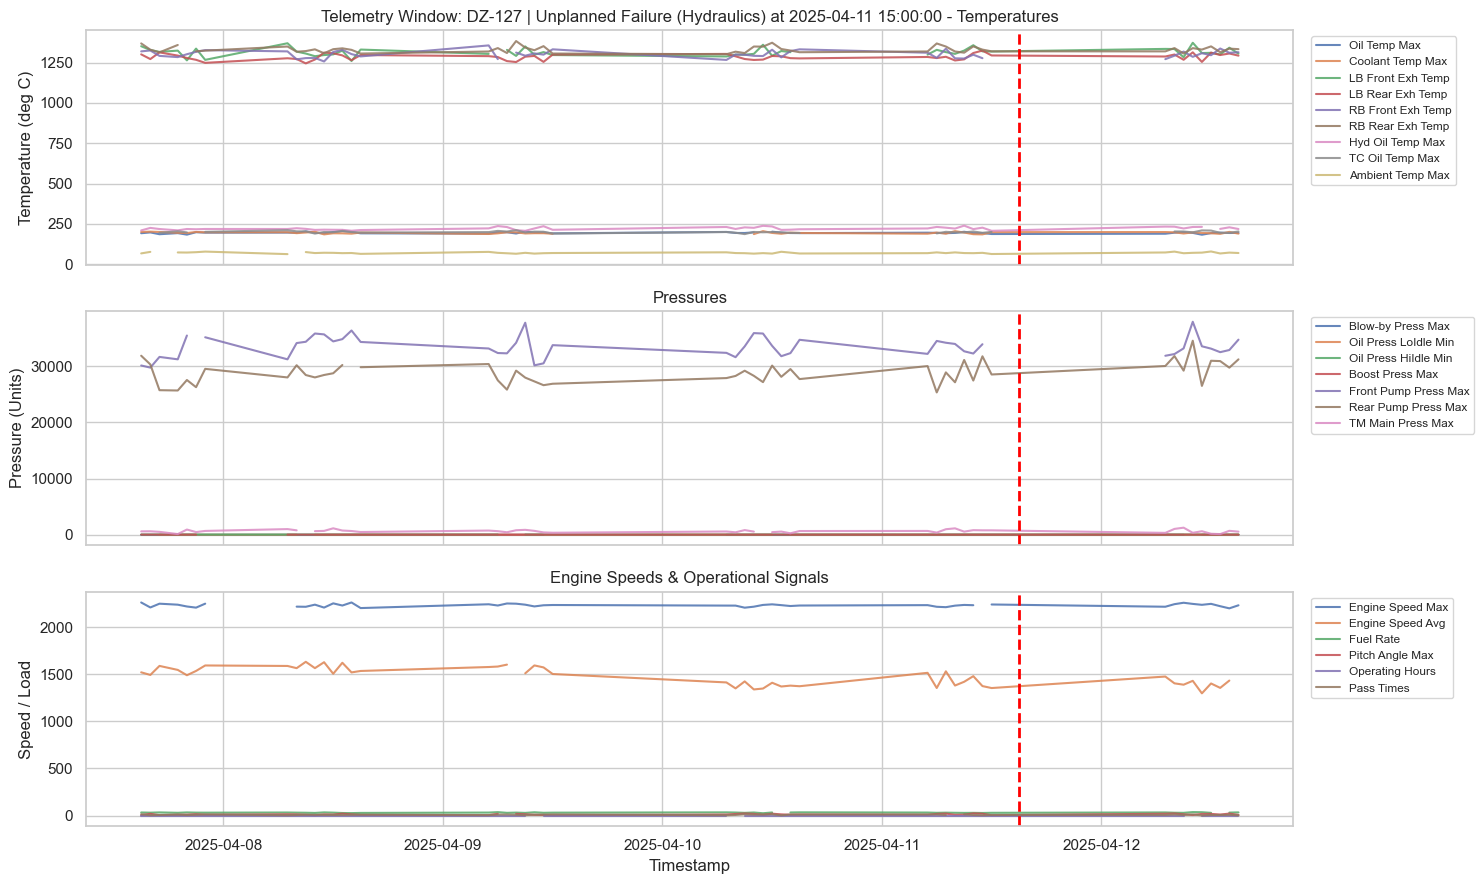

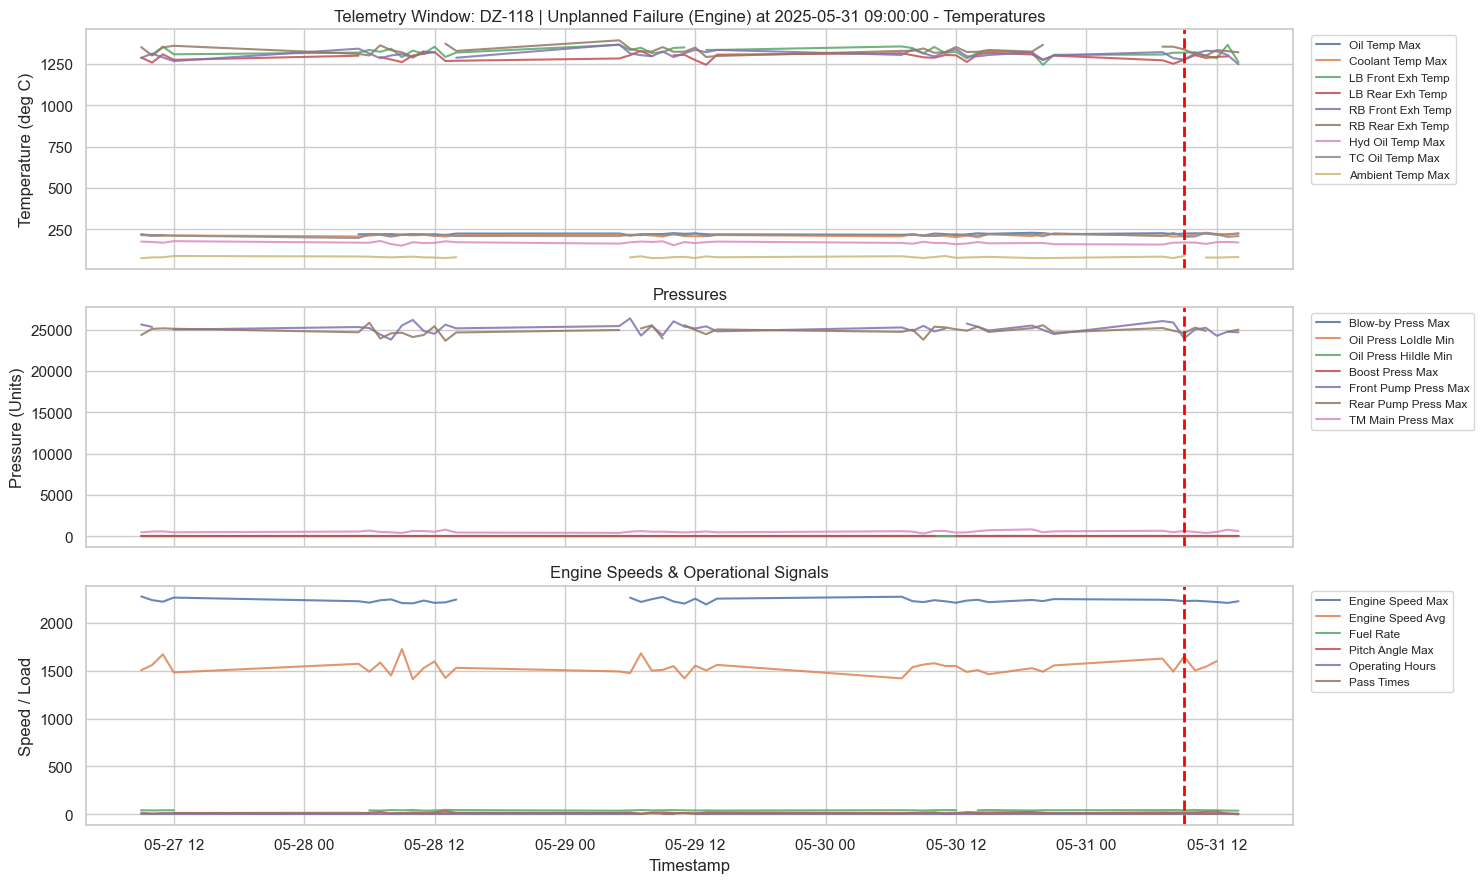

In [26]:
temp_cols = [c for c in sensor_cols if "Temp" in c]
press_cols = [c for c in sensor_cols if "Press" in c]
other_cols = [c for c in sensor_cols if c not in temp_cols and c not in press_cols]

for _, event in events.iterrows():
    m_id = event["Machine ID"]
    e_time = pd.to_datetime(event["Event Timestamp"])
    cat = event["Category"]
    comp = event["Component"] if pd.notna(event.get("Component")) else "General"
    
    sub = telemetry[(telemetry["Machine ID"] == m_id) & 
                    (pd.to_datetime(telemetry["Timestamp"]).between(e_time - pd.Timedelta(hours=96), e_time + pd.Timedelta(hours=24)))].copy()
    
    if sub.empty:
        continue
    
    sub["Timestamp"] = pd.to_datetime(sub["Timestamp"])
    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
    
    # 1. Temperatures
    for col in temp_cols:
        axes[0].plot(sub["Timestamp"], sub[col], label=col, alpha=0.85)
    axes[0].axvline(e_time, color="red" if cat == "Unplanned Failure" else "orange", linestyle="--", linewidth=2)
    axes[0].set_ylabel("Temperature (deg C)")
    axes[0].set_title(f"Telemetry Window: {m_id} | {cat} ({comp}) at {e_time} - Temperatures", fontsize=12)
    axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5)
    
    # 2. Pressures
    for col in press_cols:
        axes[1].plot(sub["Timestamp"], sub[col], label=col, alpha=0.85)
    axes[1].axvline(e_time, color="red" if cat == "Unplanned Failure" else "orange", linestyle="--", linewidth=2)
    axes[1].set_ylabel("Pressure (Units)")
    axes[1].set_title("Pressures", fontsize=12)
    axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5)
    
    # 3. Speeds & Operations
    for col in other_cols:
        axes[2].plot(sub["Timestamp"], sub[col], label=col, alpha=0.85)
    axes[2].axvline(e_time, color="red" if cat == "Unplanned Failure" else "orange", linestyle="--", linewidth=2)
    axes[2].set_ylabel("Speed / Load")
    axes[2].set_title("Engine Speeds & Operational Signals", fontsize=12)
    axes[2].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5)
    
    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()
